In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import math
from matplotlib import colormaps
from scipy.integrate import quad

In [2]:
def psi_func(x, mu, sigma):
    return (np.exp(-(x-mu)**2 / (2 * sigma**2)) + np.exp(-(x+mu)**2 / (2 * sigma**2)))**2

def Vpot(x):
    return (x**2 - 2.5)*x**2

### Simulated Annealing algorithm

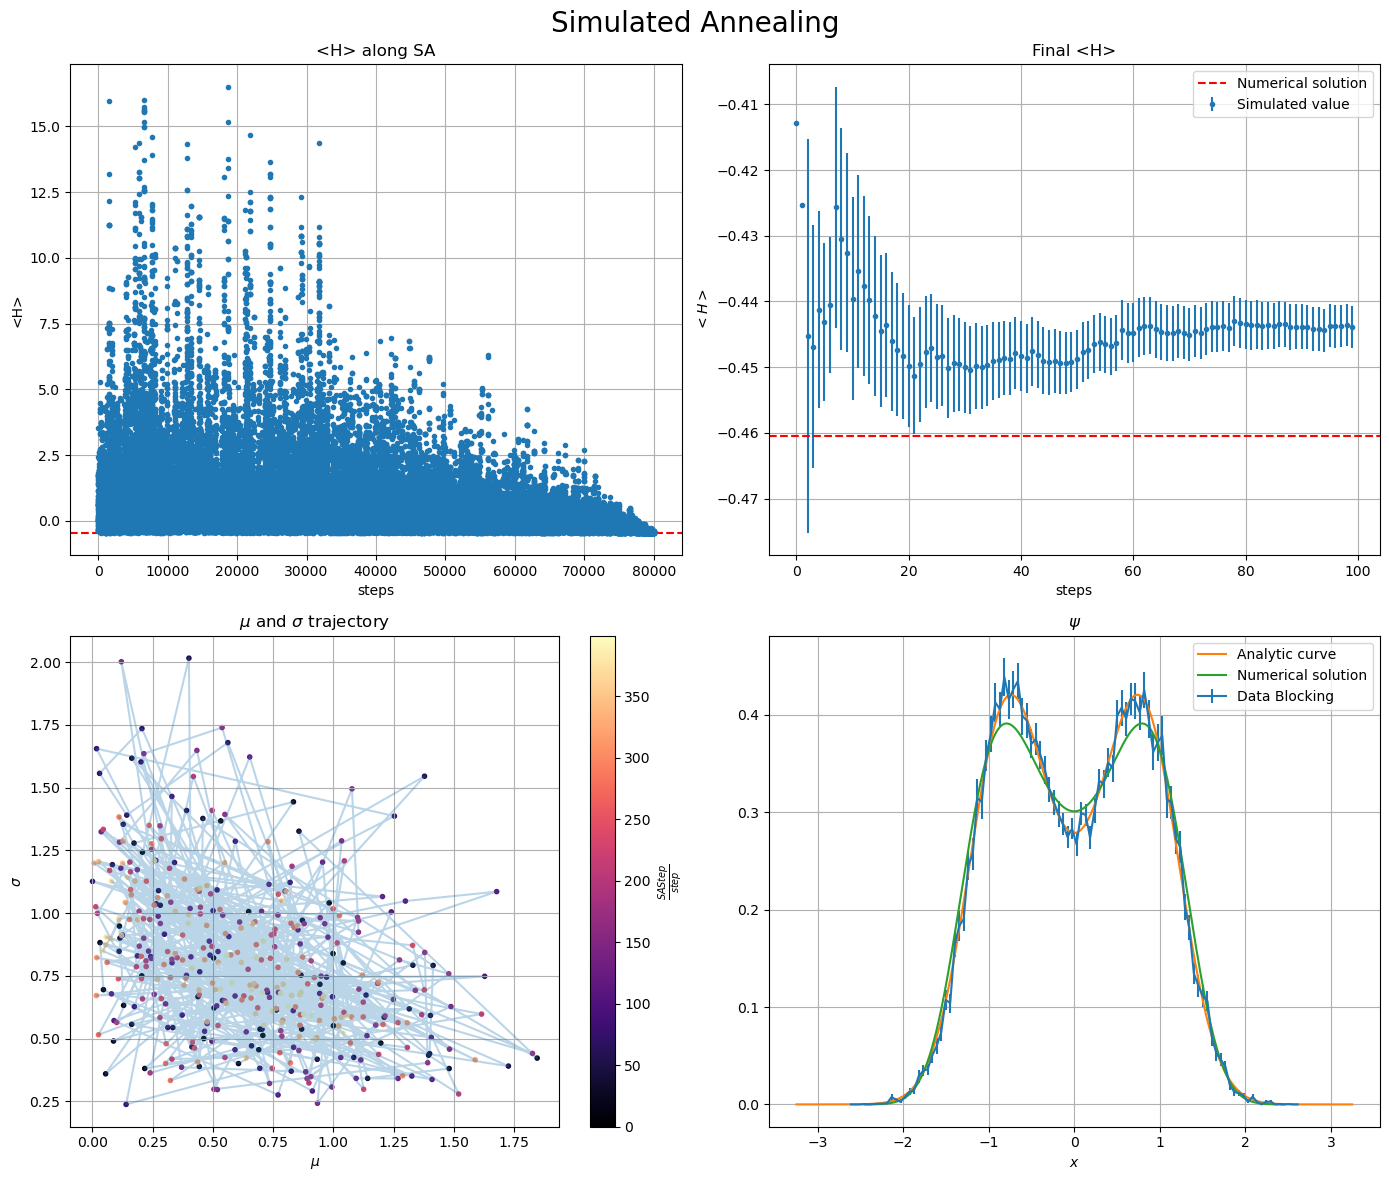

Optimal values of:
mu = 0.803135
sigma = 0.611106
H = -0.44383 +- 0.00318215


In [3]:
T, mu, sigma, H_SA, err = np.loadtxt('Dati.dat', usecols=(0,1,2,3,4), skiprows=1, unpack=True)
SA_steps = np.arange(len(T))
steps, H_fin, H_err = np.loadtxt('H.dat', unpack=True)
bin, psi, psi_err = np.loadtxt('Psi.dat', skiprows=1, unpack=True)

mu_fin, sigma_fin = mu[-1], sigma[-1]
x = np.linspace(-(4*sigma_fin+mu_fin), 4*sigma_fin+mu_fin, 1000)
analytic = psi_func(x, mu_fin, sigma_fin) / quad(psi_func, -np.inf, np.inf, args=(mu_fin, sigma_fin))[0]

hbar = 1
m = 1
a = 8*sigma_fin
N = 1000 # number of iterations

x_mat = np.linspace(-a/2, a/2, N)
dx = x_mat[1] - x_mat[0] # the step size
V = Vpot(x_mat)
CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
E,psi_mat = np.linalg.eigh(H)
psi_mat = np.transpose(psi_mat)
psi_mat = psi_mat/np.sqrt(dx)

fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax = ax.flatten()

ax[0].errorbar(SA_steps, H_SA, fmt='.')
ax[0].axhline(y=-0.46046587969271513,linestyle='--',color='red')
ax[0].set_title("<H> along SA")
ax[0].set_xlabel("steps")
ax[0].set_ylabel("<H>")
ax[0].grid(True)

ax[1].errorbar(steps, H_fin, yerr=H_err, fmt='.', label='Simulated value')
ax[1].axhline(y=-0.46046587969271513,linestyle='--',color='red', label='Numerical solution')
ax[1].set_title("Final <H>")
ax[1].set_xlabel("steps")
ax[1].set_ylabel("$<H>$")
ax[1].legend()
ax[1].grid(True)

salto = 200
c_values = np.arange(len(SA_steps)/salto)
scatt = ax[2].scatter(mu[::salto],sigma[::salto],marker=".",c=c_values,cmap="magma")
ax[2].plot(mu[::salto],sigma[::salto],alpha=0.3)
ax[2].set_xlabel("$\\mu$")
ax[2].set_ylabel("$\\sigma$")
ax[2].set_title("$\\mu$ and $\\sigma$ trajectory")
cbar = fig.colorbar(scatt, ax=ax[2])
cbar.set_label("$\\frac{SA Step}{{step}}$", fontsize=10)
ax[2].grid(True)

ax[3].errorbar(bin,psi,yerr=psi_err,label="Data Blocking")
ax[3].plot(x,analytic,label="Analytic curve")
ax[3].plot(x_mat, psi_mat[0]**2,label="Numerical solution")
ax[3].set_title("$\\psi$")
ax[3].set_xlabel("$x$")
ax[3].legend()
ax[3].grid(True)

fig.suptitle("Simulated Annealing", fontsize= 20)
plt.tight_layout()
plt.show()
print(f"Optimal values of:\nmu = {mu_fin}\nsigma = {sigma_fin}\nH = {H_fin[-1]} +- {H_err[-1]}")

### Commenti
La simulazione viene svolta con $M_{SA} = 80000$ iterazioni lungo cui viene fatta decrescere linearmente la temperatura, da un valore iniziale $T_0 = 3.0$ ad un valore finale $T_f = 0.0075$. La temperatura diminuisce ogni $L_{SA} = 200$ step del Simulated Annealing, in modo da avere $N_{SA} = M_{SA}/L_{SA} = 400$ "gradini" di temperatura.\
Al termine della simulazione risultano dei valori finali dei parametri pari a quelli stampati sotto i grafici. Con questi valori ottimali è stata condotta una simulazione dell'energia, e con il valore finale di quest'ultima è stato poi campionato il modulo quadro della funzione d'onda di minima energia.

Dall'andamento del primo grafico notiamo che l'algoritmo, partendo da una stima relativamente alta dell'energia, si abbassa progressivamente tendendo ad un valore sempre più vicino a quello proprio della soluzione numerica.\
La validità del risultato finale dell'energia si riscontra anche da come il modulo quadro della funzione d'onda $|\psi (x)|^2$, rappresentata nel quarto grafico, si sovrapponga appieno alla funzione analitica e alla soluzione numerica. Tuttavia dal secondo grafico si osserva una incompatibilità di questo valore con la soluzione (i due valori distano diversi multipli dell'incertezza statistica). Questa imprecisione può essere ridotta allungando i tempi della simulazione (tramite il numero di iterazioni $M_{SA}$ e di $L_{SA}$), ma anche aumentando progressivamente il numero di MC steps di ciascuna simulazione man mano che diminuisce la temperatura, così come regolando i parametri dell'algoritmo (in particolare il $\delta_x$) in modo da avere un accettazione sempre intorno al $50\%$.